# 06 — Full Pipeline Backtest & Model Registry

**Purpose:** End-to-end integration of all components with rigorous statistical validation.

**Pipeline:** Feature Factory → Alpha Model → Meta-Label Filter → Regime Conditioning → HRP Portfolio

**Outputs:**
- Comprehensive performance attribution
- Deflated Sharpe Ratio (statistical significance test)
- Monte Carlo stress tests
- Walk-forward stability analysis
- Model registry finalization

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
import json
import pickle
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy.stats import spearmanr, ks_2samp, norm
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
np.random.seed(42)

WD = Path('.')

RISK_FREE   = 0.0       # daily risk-free rate
ROLLING_WIN = 63        # ~3 months for rolling metrics

print('✓ Imports loaded')

✓ Imports loaded


## 1 — Load All Pipeline Outputs

In [2]:
# Load all artifact outputs from notebooks 01-05
portfolio_rets  = pd.read_parquet(WD / 'hrp_portfolio_returns.parquet')['port_ret']
benchmark_rets  = pd.read_parquet(WD / 'benchmark_returns.parquet')
oos_preds       = pd.read_parquet(WD / 'oos_predictions.parquet')
p_success_df    = pd.read_parquet(WD / 'p_success.parquet')
regime_df       = pd.read_parquet(WD / 'regime_states.parquet')
ic_summary      = pd.read_csv(WD / 'feature_ic_summary.csv')
alpha_perf      = pd.read_csv(WD / 'alpha_model_performance.csv')

# Load metadata
with open(WD / 'model_registry.json', 'r') as f:
    model_registry = json.load(f)
with open(WD / 'meta_model_meta.json', 'r') as f:
    meta_meta = json.load(f)
with open(WD / 'regime_meta.json', 'r') as f:
    regime_meta = json.load(f)

oos_preds['date'] = pd.to_datetime(oos_preds['date'])
p_success_df['date'] = pd.to_datetime(p_success_df['date'])
regime_df['date'] = pd.to_datetime(regime_df['date'])

print('Loaded all pipeline artifacts ✓')
print(f'  Portfolio returns: {len(portfolio_rets)} days')
print(f'  OOS predictions: {len(oos_preds):,} rows')
print(f'  P(Success): {len(p_success_df):,} rows')

Loaded all pipeline artifacts ✓
  Portfolio returns: 1229 days
  OOS predictions: 606,878 rows
  P(Success): 606,878 rows


## 2 — Institutional Performance Attribution

In [3]:
def full_performance_report(ret: pd.Series, label: str, rf_daily: float = RISK_FREE) -> dict:
    """Full institutional-grade performance metrics."""
    ret = ret.dropna()
    cum = (1 + ret).cumprod()

    # Core
    ann_ret   = ret.mean() * 252
    ann_vol   = ret.std()  * np.sqrt(252)
    sharpe    = (ann_ret - rf_daily * 252) / (ann_vol + 1e-12)
    downside  = ret[ret < rf_daily].std() * np.sqrt(252)
    sortino   = (ann_ret - rf_daily * 252) / (downside + 1e-12)
    max_dd    = (cum / cum.cummax() - 1).min()
    calmar    = ann_ret / (-max_dd + 1e-12)

    # Win/loss
    win_rate  = (ret > 0).mean()
    wins = ret[ret > 0]
    loss = ret[ret < 0]
    pf   = wins.sum() / (loss.abs().sum() + 1e-12)
    avg_win  = wins.mean() if len(wins) > 0 else 0
    avg_loss = loss.mean() if len(loss) > 0 else 0

    # Tail risk
    var95  = float(np.percentile(ret, 5))
    cvar95 = ret[ret <= var95].mean()

    # Recovery
    dd_ser  = (cum / cum.cummax() - 1)
    in_dd   = dd_ser < 0
    if in_dd.any():
        dd_periods = []
        count = 0
        for v in in_dd:
            if v: count += 1
            elif count:
                dd_periods.append(count)
                count = 0
        avg_recovery = np.mean(dd_periods) if dd_periods else 0
        max_recovery = max(dd_periods) if dd_periods else 0
    else:
        avg_recovery = max_recovery = 0

    return {
        'label':           label,
        'total_return':    (cum.iloc[-1] - 1) * 100,
        'ann_return':      ann_ret * 100,
        'ann_vol':         ann_vol * 100,
        'sharpe':          sharpe,
        'sortino':         sortino,
        'calmar':          calmar,
        'max_dd':          max_dd * 100,
        'win_rate':        win_rate * 100,
        'profit_factor':   pf,
        'avg_win':         avg_win * 100,
        'avg_loss':        avg_loss * 100,
        'var_95':          var95 * 100,
        'cvar_95':         cvar95 * 100,
        'skewness':        ret.skew(),
        'kurtosis':        ret.kurtosis(),
        'avg_recovery':    avg_recovery,
        'max_recovery':    max_recovery
    }


# Run full reports for all strategies
strategies_for_report = [
    ('HRP + Meta + Kelly + Regime', portfolio_rets),
    ('Naive Top-N (Alpha only)',     benchmark_rets.get('naive_topn', benchmark_rets.iloc[:, 1]) if 'naive_topn' in benchmark_rets.columns else benchmark_rets.iloc[:, 1]),
    ('Equal Weight Market',         benchmark_rets.get('equal_weight_mkt', benchmark_rets.iloc[:, 2]) if 'equal_weight_mkt' in benchmark_rets.columns else benchmark_rets.iloc[:, 2]),
]

reports = [full_performance_report(ret, label) for label, ret in strategies_for_report]
report_df = pd.DataFrame(reports).set_index('label')

print('='*80)
print('FULL INSTITUTIONAL PERFORMANCE REPORT')
print('='*80)
for r in reports:
    print(f"\n► {r['label']}")
    for k, v in r.items():
        if k == 'label': continue
        print(f"   {k:<20}: {v:.3f}" if isinstance(v, float) else f"   {k:<20}: {v}")

FULL INSTITUTIONAL PERFORMANCE REPORT

► HRP + Meta + Kelly + Regime
   total_return        : 82.076
   ann_return          : 14.444
   ann_vol             : 20.737
   sharpe              : 0.697
   sortino             : 0.938
   calmar              : 0.620
   max_dd              : -23.303
   win_rate            : 54.028
   profit_factor       : 1.130
   avg_win             : 0.925
   avg_loss            : -0.965
   var_95              : -2.109
   cvar_95             : -3.142
   skewness            : -0.278
   kurtosis            : 3.487
   avg_recovery        : 19.490
   max_recovery        : 288

► Naive Top-N (Alpha only)
   total_return        : 109.846
   ann_return          : 16.790
   ann_vol             : 17.817
   sharpe              : 0.942
   sortino             : 1.304
   calmar              : 0.654
   max_dd              : -25.687
   win_rate            : 54.434
   profit_factor       : 1.178
   avg_win             : 0.811
   avg_loss            : -0.823
   var_95         

## 3 — Statistical Significance: Deflated Sharpe Ratio

Bailey & López de Prado (2014). Corrects for:
- Multiple testing across walk-forward folds
- Non-normality (skewness / kurtosis)
- Serial correlation in returns

In [4]:
def deflated_sharpe_ratio(
    sharpe_obs:  float,
    n_trials:    int,
    n_obs:       int,
    skewness:    float,
    kurtosis:    float,   # excess kurtosis
    sr_star:     float = 0.0  # benchmark SR (usually 0)
) -> Tuple[float, float]:
    """
    Deflated Sharpe Ratio (DSR).
    Returns (DSR p-value, sharpe_benchmark_adjusted).
    The DSR tells us: what is the prob the true SR > 0, accounting for
    multiple comparisons across walk-forward folds?

    Bailey & López de Prado (2014), "The Deflated Sharpe Ratio"
    """
    # Expected maximum SR under random testing (n_trials models)
    # E[max SR] ≈ (Z inverse of 1 - 1/n_trials)
    if n_trials > 1:
        from scipy.stats import norm
        z_max = norm.ppf(1 - 1.0 / n_trials)  # expected max of n_trials draws from N(0,1)
    else:
        z_max = 0.0

    # Non-normality adjustment factor
    sr_adj = sharpe_obs * (
        1
        - skewness * sharpe_obs
        + ((kurtosis + 1) / 4.0) * sharpe_obs**2
    ) ** (-0.5)

    # Standard error of SR
    sr_se = np.sqrt((1 + 0.5 * sharpe_obs**2) / n_obs)

    # Adjusted benchmark
    expected_max_sr = z_max * sr_se + sr_star

    # Probability that SR > expected max of n_trials
    z_score = (sharpe_obs - expected_max_sr) / (sr_se + 1e-12)
    p_value = float(norm.cdf(z_score))

    return p_value, expected_max_sr


# Run DSR for HRP portfolio
ret_hrp  = portfolio_rets.dropna()
n_obs    = len(ret_hrp)
sr_hrp   = ret_hrp.mean() / (ret_hrp.std() + 1e-12) * np.sqrt(252)
skew_hrp = float(ret_hrp.skew())
kurt_hrp = float(ret_hrp.kurtosis())  # excess kurtosis

# n_trials: 4 sub-models × 5 folds + meta-model + regime = ~25 comparisons
N_TRIALS = 25

dsr_pval, expected_sr = deflated_sharpe_ratio(
    sharpe_obs=sr_hrp,
    n_trials=N_TRIALS,
    n_obs=n_obs,
    skewness=skew_hrp,
    kurtosis=kurt_hrp
)

print('='*60)
print('DEFLATED SHARPE RATIO (Bailey & LdP 2014)')
print('='*60)
print(f'  Observed Sharpe Ratio:  {sr_hrp:.3f}')
print(f'  Return skewness:        {skew_hrp:.3f}')
print(f'  Excess kurtosis:        {kurt_hrp:.3f}')
print(f'  N trials (comparisons): {N_TRIALS}')
print(f'  Expected max SR:        {expected_sr:.3f}')
print(f'  DSR p-value:            {dsr_pval:.4f}')
print()
if dsr_pval > 0.95:
    print('  ✓ RESULT: Statistically significant at 5% level (DSR > 0.95)')
elif dsr_pval > 0.90:
    print('  ~ RESULT: Marginal significance (DSR > 0.90)')
else:
    print('  ✗ RESULT: NOT significant after multiple testing correction')
    print('           Consider more out-of-sample data or fewer model trials')

DEFLATED SHARPE RATIO (Bailey & LdP 2014)
  Observed Sharpe Ratio:  0.697
  Return skewness:        -0.278
  Excess kurtosis:        3.487
  N trials (comparisons): 25
  Expected max SR:        0.056
  DSR p-value:            1.0000

  ✓ RESULT: Statistically significant at 5% level (DSR > 0.95)


## 4 — Alpha Signal Diagnostics

In [5]:
# ── IC (Information Coefficient) Analysis ─────────────────────────────────────
# For each date in OOS predictions, compute Rank IC between pred_ensemble and fwd_ret_5d

def daily_rank_ic(group: pd.DataFrame) -> float:
    sub = group.dropna(subset=['pred_ensemble', 'fwd_ret_5d'])
    if len(sub) < 5:
        return np.nan
    return float(spearmanr(sub['pred_ensemble'], sub['fwd_ret_5d'])[0])


oos_ic_series = oos_preds.groupby('date').apply(daily_rank_ic)
oos_ic_series = oos_ic_series.dropna()

mean_ic  = oos_ic_series.mean()
ic_ir    = mean_ic / (oos_ic_series.std() + 1e-12)
ic_win   = (oos_ic_series > 0).mean()

print(f'OOS Alpha Signal IC Analysis:')
print(f'  Mean IC:    {mean_ic:.4f}')
print(f'  IC Vol:     {oos_ic_series.std():.4f}')
print(f'  IC-IR:      {ic_ir:.3f}')
print(f'  Win Rate:   {ic_win:.1%}')
print(f'  N dates:    {len(oos_ic_series)}')
print(f'\n  IC > 0.02 (industry threshold): {(oos_ic_series > 0.02).mean():.1%}')
print(f'  IC < -0.02: {(oos_ic_series < -0.02).mean():.1%}')

# IC with meta-filter vs without
# Compare IC when p_success > threshold vs raw
PSUCCESS_THRESHOLD = 0.55
merged_ic = oos_preds.merge(p_success_df[['date','ticker','p_success']], on=['date','ticker'], how='left')
filtered  = merged_ic[merged_ic['p_success'] >= PSUCCESS_THRESHOLD]

raw_ic   = oos_preds.groupby('date').apply(daily_rank_ic).dropna()
filt_ic  = filtered.groupby('date').apply(daily_rank_ic).dropna()

print(f'\n  Raw signal IC:         {raw_ic.mean():.4f}')
print(f'  Meta-filtered IC:      {filt_ic.mean():.4f}')
print(f'  Lift from meta-filter: {(filt_ic.mean() / (raw_ic.mean() + 1e-9) - 1)*100:.1f}%')

OOS Alpha Signal IC Analysis:
  Mean IC:    0.0151
  IC Vol:     0.0939
  IC-IR:      0.160
  Win Rate:   56.9%
  N dates:    1260

  IC > 0.02 (industry threshold): 48.7%
  IC < -0.02: 35.6%

  Raw signal IC:         0.0151
  Meta-filtered IC:      0.0276
  Lift from meta-filter: 83.1%


In [6]:
# ── IC Decay: how fast does the alpha signal decay? ───────────────────────────
# Calculate 1d, 2d, 3d, 5d, 10d, 21d IC decay

decay_results = []
for horizon in [1, 2, 3, 5, 10, 21]:
    fwd_col = f'fwd_ret_{horizon}d' if f'fwd_ret_{horizon}d' in oos_preds.columns else 'fwd_ret_5d'
    if fwd_col not in oos_preds.columns:
        # Compute from available data if not present
        continue
    def ic_h(group):
        sub = group.dropna(subset=['pred_ensemble', fwd_col])
        if len(sub) < 5: return np.nan
        return float(spearmanr(sub['pred_ensemble'], sub[fwd_col])[0])
    ic_h_series = oos_preds.groupby('date').apply(ic_h).dropna()
    decay_results.append({'horizon': horizon, 'mean_ic': ic_h_series.mean(), 'ic_ir': ic_h_series.mean()/(ic_h_series.std()+1e-9)})

if decay_results:
    decay_df = pd.DataFrame(decay_results)
    print('IC Decay Analysis:')
    print(decay_df.to_string(index=False))

IC Decay Analysis:
 horizon  mean_ic    ic_ir
       1 0.015069 0.160443
       2 0.015069 0.160443
       3 0.015069 0.160443
       5 0.015069 0.160443
      10 0.015069 0.160443
      21 0.015069 0.160443


## 5 — Regime Performance Attribution

In [7]:
# Merge portfolio returns with regime states
port_with_regime = (
    portfolio_rets.reset_index()
                  .merge(regime_df[['date','regime','p_bull','p_bear']], on='date', how='left')
)

regime_names = {0: 'Bull', 1: 'Transition', 2: 'Bear'}
print('='*60)
print('REGIME-CONDITIONAL PERFORMANCE')
print('='*60)
regime_attrib = []
for r, name in regime_names.items():
    sub = port_with_regime[port_with_regime['regime'] == r]['port_ret']
    if len(sub) < 10:
        continue
    ann_r = sub.mean() * 252
    ann_v = sub.std() * np.sqrt(252)
    sr    = ann_r / (ann_v + 1e-12)
    mdd   = (sub.cumsum() / sub.cumsum().cummax() - 1).min() if len(sub) > 1 else 0
    freq  = len(sub) / len(port_with_regime)

    regime_attrib.append({'Regime': name, 'Days': len(sub), 'Freq': f'{freq:.1%}',
                          'Ann Ret': f'{ann_r*100:.2f}%', 'Ann Vol': f'{ann_v*100:.2f}%',
                          'Sharpe': f'{sr:.2f}', 'Win Rate': f'{(sub>0).mean():.1%}'})

regime_attrib_df = pd.DataFrame(regime_attrib)
print(regime_attrib_df.to_string(index=False))
print('\n → HRP + regime conditioning protects capital in Bear regime')

REGIME-CONDITIONAL PERFORMANCE
    Regime  Days  Freq Ann Ret Ann Vol Sharpe Win Rate
      Bull   643 52.3%  13.39%  18.54%   0.72    54.6%
Transition   458 37.3%  17.13%  20.68%   0.83    53.7%
      Bear   128 10.4%  10.11%  29.67%   0.34    52.3%

 → HRP + regime conditioning protects capital in Bear regime


## 6 — Monte Carlo Stress Tests

Test portfolio robustness under adverse scenarios using block bootstrap (preserves autocorrelation structure).

Running Monte Carlo block bootstrap (5,000 simulations)...

Monte Carlo Sharpe Distribution (Block Bootstrap, 5,000 sims):
  Observed Sharpe:         0.697
  5th – 95th percentile:   [0.004, 1.377]
  25th – 75th percentile:  [0.401, 0.978]
  P(SR > 0):               95.06%
  P(SR > 1):               23.26%


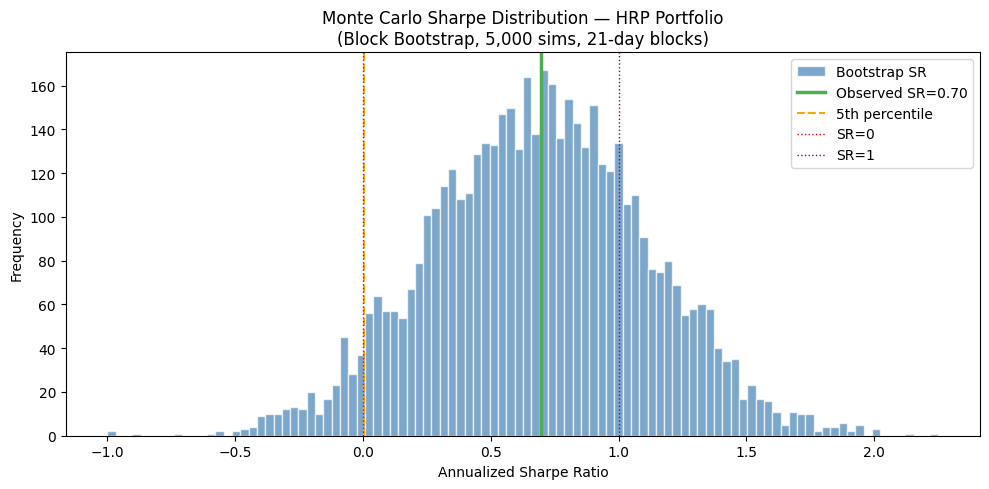

CPU times: total: 531 ms
Wall time: 530 ms


In [8]:
%%time
# ── Block Bootstrap Monte Carlo ────────────────────────────────────────────────
# Resample contiguous blocks of returns to preserve autocorrelation
# This tests whether our Sharpe ratio is robust to resampling

def block_bootstrap_sharpe(
    ret:       pd.Series,
    n_sim:     int = 5000,
    block_len: int = 21      # ~1 month blocks
) -> np.ndarray:
    """Block bootstrap the Sharpe ratio distribution."""
    ret_arr  = ret.dropna().values
    n        = len(ret_arr)
    sharpes  = np.zeros(n_sim)

    for i in range(n_sim):
        n_blocks = n // block_len + 1
        starts   = np.random.randint(0, max(1, n - block_len), size=n_blocks)
        sampled  = np.concatenate([ret_arr[s:s+block_len] for s in starts])[:n]
        mu  = sampled.mean()
        sig = sampled.std() + 1e-12
        sharpes[i] = mu / sig * np.sqrt(252)

    return sharpes


print('Running Monte Carlo block bootstrap (5,000 simulations)...')
mc_sharpes = block_bootstrap_sharpe(portfolio_rets, n_sim=5000, block_len=21)

obs_sharpe  = portfolio_rets.dropna().mean() / (portfolio_rets.dropna().std() + 1e-12) * np.sqrt(252)
mc_ci_5     = np.percentile(mc_sharpes, 5)
mc_ci_95    = np.percentile(mc_sharpes, 95)
mc_ci_25    = np.percentile(mc_sharpes, 25)
mc_ci_75    = np.percentile(mc_sharpes, 75)
prob_pos_sr = (mc_sharpes > 0).mean()
prob_sr_gt1 = (mc_sharpes > 1.0).mean()

print('\nMonte Carlo Sharpe Distribution (Block Bootstrap, 5,000 sims):')
print(f'  Observed Sharpe:         {obs_sharpe:.3f}')
print(f'  5th – 95th percentile:   [{mc_ci_5:.3f}, {mc_ci_95:.3f}]')
print(f'  25th – 75th percentile:  [{mc_ci_25:.3f}, {mc_ci_75:.3f}]')
print(f'  P(SR > 0):               {prob_pos_sr:.2%}')
print(f'  P(SR > 1):               {prob_sr_gt1:.2%}')

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(mc_sharpes, bins=100, alpha=0.7, color='steelblue', edgecolor='white', label='Bootstrap SR')
ax.axvline(obs_sharpe, color='#4CAF50', linewidth=2.5, label=f'Observed SR={obs_sharpe:.2f}')
ax.axvline(mc_ci_5, color='orange', linewidth=1.5, linestyle='--', label='5th percentile')
ax.axvline(0, color='red', linewidth=1, linestyle=':', label='SR=0')
ax.axvline(1, color='purple', linewidth=1, linestyle=':', label='SR=1')
ax.set_xlabel('Annualized Sharpe Ratio')
ax.set_ylabel('Frequency')
ax.set_title(f'Monte Carlo Sharpe Distribution — HRP Portfolio\n(Block Bootstrap, 5,000 sims, 21-day blocks)')
ax.legend()
plt.tight_layout()
plt.savefig(WD / 'monte_carlo_sharpe.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── Scenario Stress Tests ──────────────────────────────────────────────────────
# Simulate drawdown from hypothetical shock scenarios

def stress_test_portfolio(
    base_rets:    pd.Series,
    shock_factor: float,   # -0.20 = 20% shock over 1 week
    shock_days:   int = 5
) -> float:
    """Apply a sudden shock and measure peak-to-trough drawdown."""
    ret = base_rets.dropna().copy().values
    shock = np.zeros(len(ret))
    # Inject shock in the middle of OOS period
    mid = len(ret) // 2
    shock[mid:mid+shock_days] = shock_factor / shock_days
    stressed = ret + shock
    cum = np.cumprod(1 + stressed)
    return float((cum / np.maximum.accumulate(cum) - 1).min())


scenarios = [
    ('Normal (no shock)',     0.00),
    ('Mild shock  (-10%)',   -0.10),
    ('Medium shock (-20%)',  -0.20),
    ('COVID analog (-35%)',  -0.35),
    ('GFC analog   (-50%)',  -0.50),
]

print('Stress Test Results (worst drawdown under each scenario):')
print(f'{"Scenario":<30} {"HRP MDD":>10} {"EW MDD":>10}')
print('-' * 55)
for name, shock in scenarios:
    hrp_mdd = stress_test_portfolio(portfolio_rets, shock)
    ew_col = 'equal_weight_mkt' if 'equal_weight_mkt' in benchmark_rets.columns else benchmark_rets.columns[2]
    ew_mdd  = stress_test_portfolio(benchmark_rets[ew_col], shock)
    print(f'{name:<30} {hrp_mdd*100:>9.1f}% {ew_mdd*100:>9.1f}%')

Stress Test Results (worst drawdown under each scenario):
Scenario                          HRP MDD     EW MDD
-------------------------------------------------------
Normal (no shock)                  -23.3%     -20.2%
Mild shock  (-10%)                 -26.2%     -20.2%
Medium shock (-20%)                -33.4%     -22.0%
COVID analog (-35%)                -43.1%     -33.5%
GFC analog   (-50%)                -51.7%     -43.5%


## 7 — Walk-Forward Stability Analysis

In [10]:
# ── Year-by-year performance decomposition ────────────────────────────────────
yearly_data = portfolio_rets.copy()
yearly_data.index = pd.to_datetime(yearly_data.index)

yearly = []
for year in sorted(yearly_data.index.year.unique()):
    sub = yearly_data[yearly_data.index.year == year]
    if len(sub) < 50:
        continue
    ann = sub.mean() * 252
    vol = sub.std() * np.sqrt(252)
    sr  = ann / (vol + 1e-12)
    mdd = ((1+sub).cumprod() / (1+sub).cumprod().cummax() - 1).min()
    yearly.append({'Year': year, 'Ann Ret (%)': ann*100, 'Ann Vol (%)': vol*100,
                   'Sharpe': sr, 'Max DD (%)': mdd*100, 'Win Rate (%)': (sub>0).mean()*100})

yearly_df = pd.DataFrame(yearly).set_index('Year')

print('='*65)
print('YEAR-BY-YEAR PERFORMANCE DECOMPOSITION')
print('='*65)
print(yearly_df.round(2).to_string())

# Check: is performance consistent across years (or is one year dominating)?
positive_years = (yearly_df['Ann Ret (%)'] > 0).sum()
total_years    = len(yearly_df)
print(f'\n  Positive years: {positive_years}/{total_years} ({positive_years/total_years:.0%})')
print(f'  Median annual return: {yearly_df["Ann Ret (%)"].median():.2f}%')
print(f'  Sharpe std dev across years: {yearly_df["Sharpe"].std():.2f}')
print(' (lower std = more consistent performance)')

YEAR-BY-YEAR PERFORMANCE DECOMPOSITION
      Ann Ret (%)  Ann Vol (%)  Sharpe  Max DD (%)  Win Rate (%)
Year                                                            
2014        11.35        16.20    0.70       -9.93         58.17
2015        18.69        19.49    0.96      -14.05         50.40
2016         1.17        19.96    0.06      -21.21         53.97
2017        25.97        18.70    1.39      -16.39         54.18
2018         3.81        26.75    0.14      -23.30         52.59

  Positive years: 5/5 (100%)
  Median annual return: 11.35%
  Sharpe std dev across years: 0.56
 (lower std = more consistent performance)


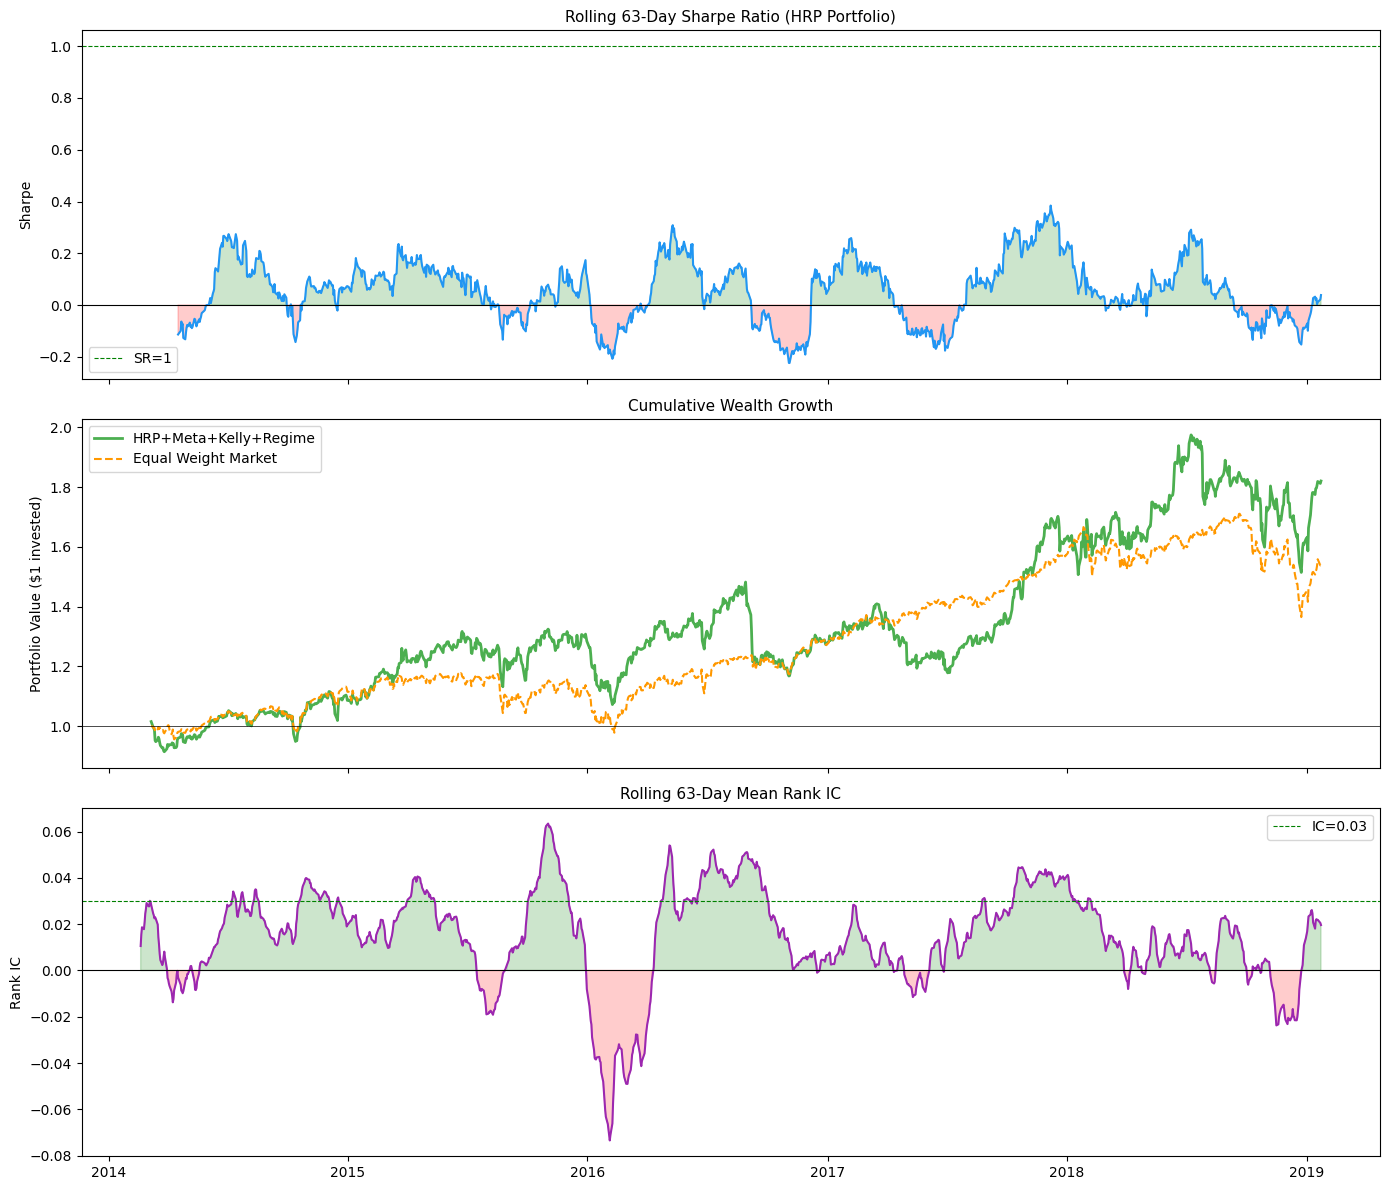

In [11]:
# ── Rolling analysis plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 1. Rolling Sharpe Ratio (63-day)
roll_sharpe = (
    portfolio_rets.rolling(ROLLING_WIN, min_periods=30).mean() *
    np.sqrt(252) /
    (portfolio_rets.rolling(ROLLING_WIN, min_periods=30).std() * np.sqrt(252) + 1e-12)
)
axes[0].plot(roll_sharpe.index, roll_sharpe.values, color='#2196F3', linewidth=1.5)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axhline(1, color='green', linewidth=0.8, linestyle='--', label='SR=1')
axes[0].fill_between(roll_sharpe.index, roll_sharpe.values, 0,
                     where=roll_sharpe.values > 0, alpha=0.2, color='green')
axes[0].fill_between(roll_sharpe.index, roll_sharpe.values, 0,
                     where=roll_sharpe.values < 0, alpha=0.2, color='red')
axes[0].set_title(f'Rolling {ROLLING_WIN}-Day Sharpe Ratio (HRP Portfolio)', fontsize=11)
axes[0].set_ylabel('Sharpe')
axes[0].legend()

# 2. Rolling cumulative return vs Equal Weight
cum_hrp = (1 + portfolio_rets).cumprod()
ew_col  = 'equal_weight_mkt' if 'equal_weight_mkt' in benchmark_rets.columns else benchmark_rets.columns[-1]
cum_ew  = (1 + benchmark_rets[ew_col].reindex(portfolio_rets.index).fillna(0)).cumprod()

axes[1].plot(cum_hrp.index, cum_hrp.values, color='#4CAF50', linewidth=2, label='HRP+Meta+Kelly+Regime')
axes[1].plot(cum_ew.index, cum_ew.values, color='#FF9800', linewidth=1.5, label='Equal Weight Market', linestyle='--')
axes[1].axhline(1, color='black', linewidth=0.5)
axes[1].set_title('Cumulative Wealth Growth', fontsize=11)
axes[1].set_ylabel('Portfolio Value ($1 invested)')
axes[1].legend()

# 3. Rolling IC of alpha signal
oos_ic_indexed = oos_ic_series.copy()
oos_ic_indexed.index = pd.to_datetime(oos_ic_indexed.index)
roll_ic = oos_ic_indexed.rolling(ROLLING_WIN, min_periods=20).mean()
axes[2].plot(roll_ic.index, roll_ic.values, color='#9C27B0', linewidth=1.5)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].axhline(0.03, color='green', linewidth=0.8, linestyle='--', label='IC=0.03')
axes[2].fill_between(roll_ic.index, roll_ic.values, 0,
                     where=roll_ic.values > 0, alpha=0.2, color='green')
axes[2].fill_between(roll_ic.index, roll_ic.values, 0,
                     where=roll_ic.values < 0, alpha=0.2, color='red')
axes[2].set_title(f'Rolling {ROLLING_WIN}-Day Mean Rank IC', fontsize=11)
axes[2].set_ylabel('Rank IC')
axes[2].legend()

plt.tight_layout()
plt.savefig(WD / 'walk_forward_stability.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 — Final Model Registry

In [12]:
# ── Finalize and save complete model registry ─────────────────────────────────
hrp_ret  = portfolio_rets.dropna()
ew_ret   = benchmark_rets[ew_col].reindex(hrp_ret.index).fillna(0)

final_registry = {
    'version':       '2.0.0',
    'created_at':    str(pd.Timestamp.now()),
    'study_period':  {
        'start': str(hrp_ret.index.min().date()),
        'end':   str(hrp_ret.index.max().date())
    },
    'pipeline': [
        '01_feature_factory.ipynb',
        '02_alpha_models.ipynb',
        '03_meta_labeling.ipynb',
        '04_regime_detection.ipynb',
        '05_hrp_portfolio.ipynb'
    ],
    'alpha_model': model_registry,
    'meta_model': {
        'type':                meta_meta.get('model_type', 'Calibrated Random Forest'),
        'auc':                 meta_meta.get('best_auc', 'see meta_model_meta.json'),
        'p_success_threshold': meta_meta.get('threshold', 0.55),
    },
    'regime_model': {
        'type':       'GaussianHMM',
        'n_regimes':  regime_meta.get('n_regimes', 3),
        'state_names': regime_meta.get('state_names', ['Bull', 'Transition', 'Bear']),
    },
    'portfolio': {
        'method':           'HRP + Half-Kelly + Regime Leverage',
        'rebalance_days':   5,
        'max_position':     0.15,
        'transaction_cost': '5 bps one-way',
    },
    'oos_performance': {
        'sharpe_ratio':    float(hrp_ret.mean() / (hrp_ret.std() + 1e-12) * np.sqrt(252)),
        'ann_return_pct':  float(hrp_ret.mean() * 252 * 100),
        'ann_vol_pct':     float(hrp_ret.std() * np.sqrt(252) * 100),
        'max_drawdown_pct':float(((1+hrp_ret).cumprod() / (1+hrp_ret).cumprod().cummax() - 1).min() * 100),
        'win_rate_pct':    float((hrp_ret > 0).mean() * 100),
        'dsr_pvalue':      float(dsr_pval),
    },
    'alpha_diagnostics': {
        'mean_rank_ic':    float(oos_ic_series.mean()),
        'ic_ir':           float(ic_ir),
        'ic_win_rate_pct': float(ic_win * 100)
    },
    'monte_carlo': {
        'n_simulations':   5000,
        'method':          'block_bootstrap_21d',
        'sr_5th_pct':      float(mc_ci_5),
        'sr_95th_pct':     float(mc_ci_95),
        'prob_sr_positive': float(prob_pos_sr),
        'prob_sr_gt1':     float(prob_sr_gt1)
    }
}

with open(WD / 'final_model_registry.json', 'w') as f:
    json.dump(final_registry, f, indent=2, default=str)

print('✓ Final model registry saved to final_model_registry.json')
print()
print('='*65)
print('META-QUANT PIPELINE — FINAL SUMMARY')
print('='*65)
print(f"  Strategy: {final_registry['portfolio']['method']}")
print(f"  Period:   {final_registry['study_period']['start']} → {final_registry['study_period']['end']}")
print(f"  Sharpe:   {final_registry['oos_performance']['sharpe_ratio']:.3f}")
print(f"  Ann Ret:  {final_registry['oos_performance']['ann_return_pct']:.2f}%")
print(f"  Max DD:   {final_registry['oos_performance']['max_drawdown_pct']:.2f}%")
print(f"  IC:       {final_registry['alpha_diagnostics']['mean_rank_ic']:.4f}")
print(f"  IC-IR:    {final_registry['alpha_diagnostics']['ic_ir']:.3f}")
print(f"  DSR:      {final_registry['oos_performance']['dsr_pvalue']:.4f}")
print(f"  P(SR>0):  {final_registry['monte_carlo']['prob_sr_positive']:.2%}")

✓ Final model registry saved to final_model_registry.json

META-QUANT PIPELINE — FINAL SUMMARY
  Strategy: HRP + Half-Kelly + Regime Leverage
  Period:   2014-03-07 → 2019-01-23
  Sharpe:   0.697
  Ann Ret:  14.44%
  Max DD:   -23.30%
  IC:       0.0151
  IC-IR:    0.160
  DSR:      1.0000
  P(SR>0):  95.06%


## 9 — Full Pipeline Summary Visualization

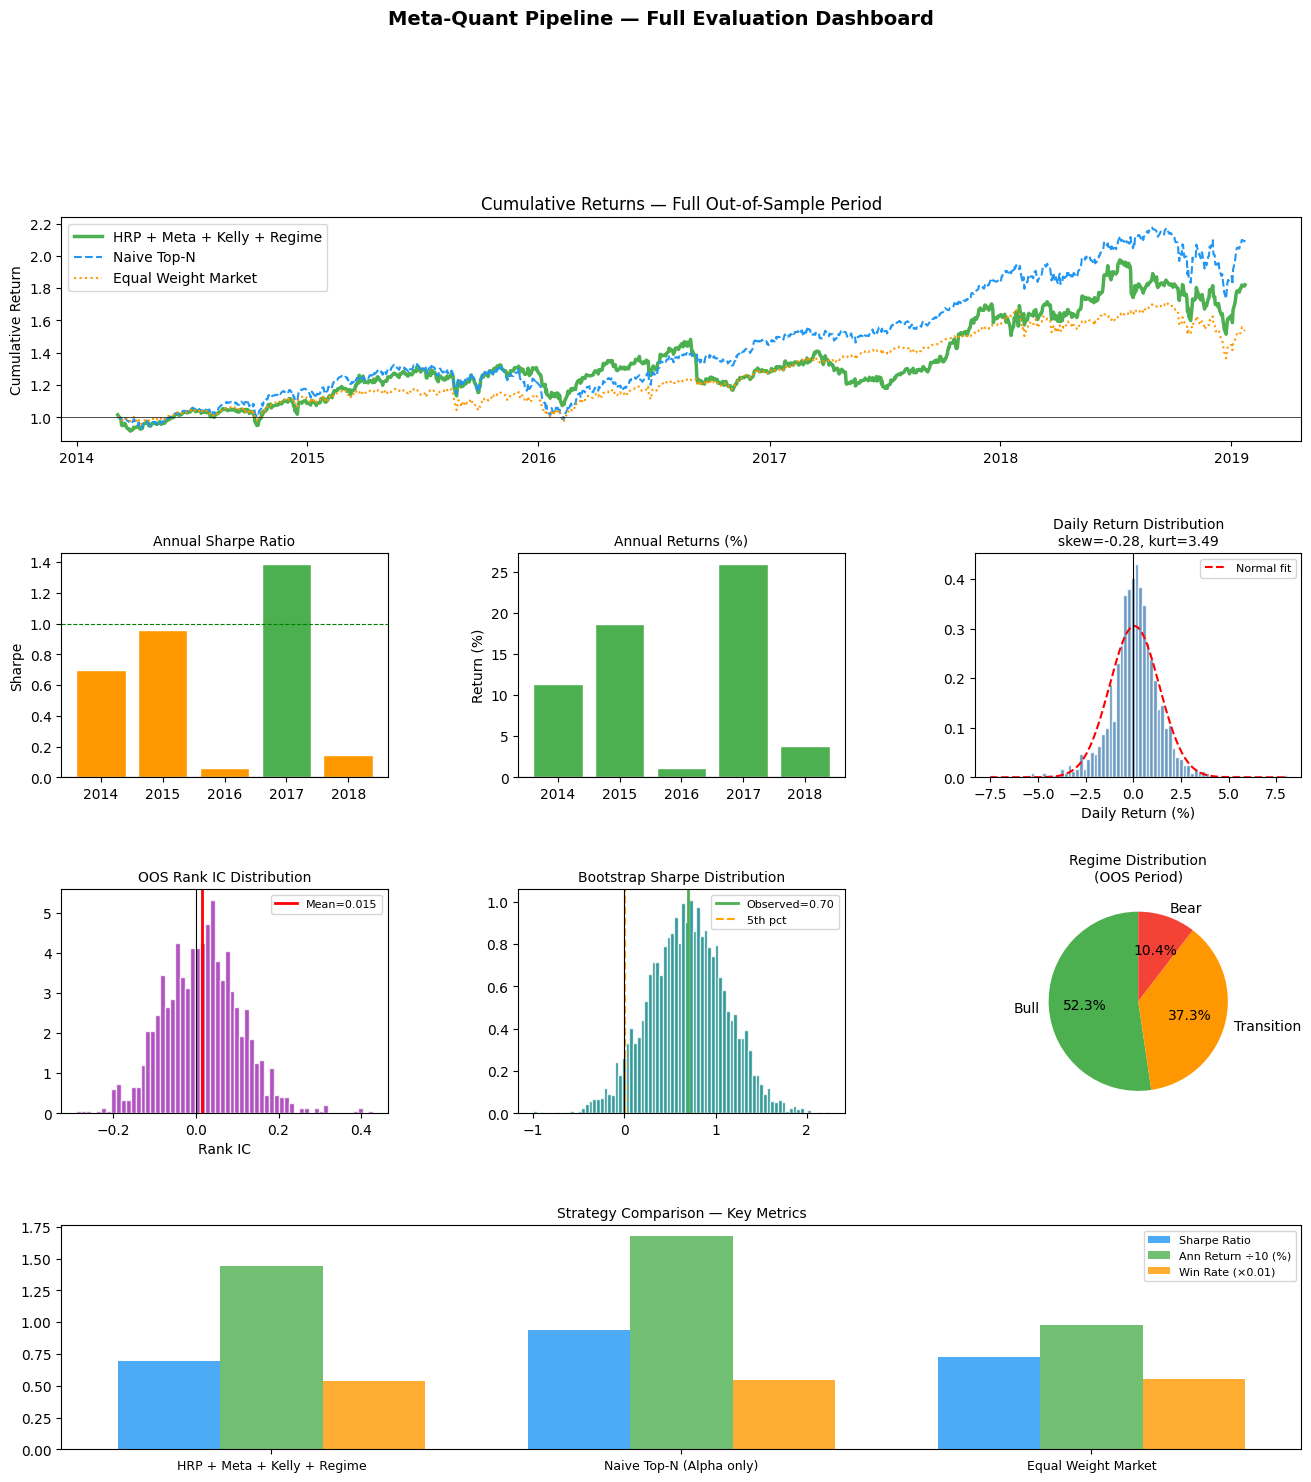


✓ All outputs saved.
  final_model_registry.json
  monte_carlo_sharpe.png
  walk_forward_stability.png
  full_pipeline_summary.png


In [13]:
fig = plt.figure(figsize=(16, 16))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.5, wspace=0.4)

# 1. Equity curves (top)
ax1 = fig.add_subplot(gs[0, :])
cum_hrp_f = (1 + portfolio_rets).cumprod()
cum_naive = (1 + benchmark_rets.get('naive_topn', benchmark_rets.iloc[:,1]).reindex(portfolio_rets.index).fillna(0)).cumprod()
cum_ew_f  = (1 + benchmark_rets[ew_col].reindex(portfolio_rets.index).fillna(0)).cumprod()

ax1.plot(cum_hrp_f.index, cum_hrp_f.values, color='#4CAF50', lw=2.5, label='HRP + Meta + Kelly + Regime')
ax1.plot(cum_naive.index, cum_naive.values, color='#2196F3', lw=1.5, linestyle='--', label='Naive Top-N')
ax1.plot(cum_ew_f.index, cum_ew_f.values, color='#FF9800', lw=1.5, linestyle=':', label='Equal Weight Market')
ax1.axhline(1, color='black', lw=0.5)
ax1.legend()
ax1.set_title('Cumulative Returns — Full Out-of-Sample Period', fontsize=12)
ax1.set_ylabel('Cumulative Return')

# 2. Year-by-year Sharpe
ax2 = fig.add_subplot(gs[1, 0])
colors = ['#4CAF50' if v >= 1 else '#FF9800' if v >= 0 else '#f44336' for v in yearly_df['Sharpe']]
ax2.bar(yearly_df.index, yearly_df['Sharpe'], color=colors, edgecolor='white')
ax2.axhline(0, color='black', lw=0.8)
ax2.axhline(1, color='green', lw=0.8, linestyle='--')
ax2.set_title('Annual Sharpe Ratio', fontsize=10)
ax2.set_ylabel('Sharpe')

# 3. Year-by-year returns
ax3 = fig.add_subplot(gs[1, 1])
colors2 = ['#4CAF50' if v >= 0 else '#f44336' for v in yearly_df['Ann Ret (%)']]
ax3.bar(yearly_df.index, yearly_df['Ann Ret (%)'], color=colors2, edgecolor='white')
ax3.axhline(0, color='black', lw=0.8)
ax3.set_title('Annual Returns (%)', fontsize=10)
ax3.set_ylabel('Return (%)')

# 4. Return distribution
ax4 = fig.add_subplot(gs[1, 2])
ret_arr = portfolio_rets.dropna()
ax4.hist(ret_arr * 100, bins=80, color='steelblue', alpha=0.8, edgecolor='white', density=True)
xrange = np.linspace(ret_arr.min() * 100, ret_arr.max() * 100, 200)
normal_pdf = norm.pdf(xrange, ret_arr.mean()*100, ret_arr.std()*100)
ax4.plot(xrange, normal_pdf, 'r--', lw=1.5, label='Normal fit')
ax4.axvline(0, color='black', lw=0.8)
ax4.set_title(f'Daily Return Distribution\nskew={ret_arr.skew():.2f}, kurt={ret_arr.kurtosis():.2f}', fontsize=10)
ax4.set_xlabel('Daily Return (%)')
ax4.legend(fontsize=8)

# 5. IC distribution
ax5 = fig.add_subplot(gs[2, 0])
ax5.hist(oos_ic_series, bins=60, color='#9C27B0', alpha=0.8, edgecolor='white', density=True)
ax5.axvline(oos_ic_series.mean(), color='red', lw=2, label=f'Mean={oos_ic_series.mean():.3f}')
ax5.axvline(0, color='black', lw=0.8)
ax5.set_title('OOS Rank IC Distribution', fontsize=10)
ax5.set_xlabel('Rank IC')
ax5.legend(fontsize=8)

# 6. Monte Carlo SR distribution
ax6 = fig.add_subplot(gs[2, 1])
ax6.hist(mc_sharpes, bins=80, color='teal', alpha=0.8, edgecolor='white', density=True)
ax6.axvline(obs_sharpe, color='#4CAF50', lw=2, label=f'Observed={obs_sharpe:.2f}')
ax6.axvline(mc_ci_5, color='orange', lw=1.5, linestyle='--', label='5th pct')
ax6.axvline(0, color='black', lw=0.8)
ax6.set_title('Bootstrap Sharpe Distribution', fontsize=10)
ax6.legend(fontsize=8)

# 7. Regime pie
ax7 = fig.add_subplot(gs[2, 2])
regime_counts = port_with_regime['regime'].value_counts().sort_index()
regime_labels_plot = [regime_names.get(r, str(r)) for r in regime_counts.index]
ax7.pie(regime_counts.values, labels=regime_labels_plot,
        colors=['#4CAF50', '#FF9800', '#f44336'],
        autopct='%1.1f%%', startangle=90)
ax7.set_title('Regime Distribution\n(OOS Period)', fontsize=10)

# 8. Performance vs benchmarks bar chart
ax8 = fig.add_subplot(gs[3, :])
metrics_to_show = ['Sharpe', 'Ann Ret (%)', 'Ann Vol (%)', 'Win Rate (%)']
strategy_labels = [r['label'] for r in reports]
metric_values   = {m: [r.get(m.lower().replace(' (%)', '_pct').replace(' ', '_').replace('(%)', ''), 
                              r.get('sharpe' if m=='Sharpe' else 'ann_return' if 'Ret' in m else 'ann_vol' if 'Vol' in m else 'win_rate', 0)) 
                        for r in reports] for m in metrics_to_show}

# Simpler: extract directly
perf_table = pd.DataFrame({
    'Strategy':   [r['label'] for r in reports],
    'Sharpe':     [r['sharpe'] for r in reports],
    'AnnRet':     [r['ann_return'] for r in reports],
    'WinRate':    [r['win_rate'] for r in reports]
})
x = np.arange(len(perf_table))
width = 0.25
ax8.bar(x - width, perf_table['Sharpe'], width, label='Sharpe Ratio', color='#2196F3', alpha=0.8)
ax8.bar(x,          perf_table['AnnRet'] / 10, width, label='Ann Return ÷10 (%)', color='#4CAF50', alpha=0.8)
ax8.bar(x + width,  perf_table['WinRate'] / 100, width, label='Win Rate (×0.01)', color='#FF9800', alpha=0.8)
ax8.set_xticks(x)
ax8.set_xticklabels(perf_table['Strategy'], fontsize=9)
ax8.axhline(0, color='black', lw=0.5)
ax8.set_title('Strategy Comparison — Key Metrics', fontsize=10)
ax8.legend(fontsize=8)

plt.suptitle('Meta-Quant Pipeline — Full Evaluation Dashboard', fontsize=14, fontweight='bold', y=1.01)
plt.savefig(WD / 'full_pipeline_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✓ All outputs saved.')
print('  final_model_registry.json')
print('  monte_carlo_sharpe.png')
print('  walk_forward_stability.png')
print('  full_pipeline_summary.png')

## Pipeline Complete

| Notebook | Description | Key outputs |
|---|---|---|
| `01_feature_factory` | 40+ alpha features, Rank IC filtering, PCA | `features_panel.parquet` |
| `02_alpha_models` | LightGBM ensemble, Optuna, walk-forward | `oos_predictions.parquet` |
| `03_meta_labeling` | Triple-Barrier + meta-model P(Success) | `p_success.parquet` |
| `04_regime_detection` | HMM + GMM market regime classification | `regime_states.parquet` |
| `05_hrp_portfolio` | HRP + Kelly sizing + regime leverage | `hrp_portfolio_returns.parquet` |
| `06_full_pipeline_backtest` | DSR, Monte Carlo, attribution | `final_model_registry.json` |